<a href="https://colab.research.google.com/github/NishanRegmi/Pytorch/blob/main/ANN_using_GPU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

In [30]:
#set seed for reproducibility
torch.manual_seed(19)

In [31]:
#check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

Using Device: cuda


In [32]:
#load dataset
df = pd.read_csv("/content/sample_data/fashion-mnist_train.csv")

In [33]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [34]:
df.shape

(60000, 785)

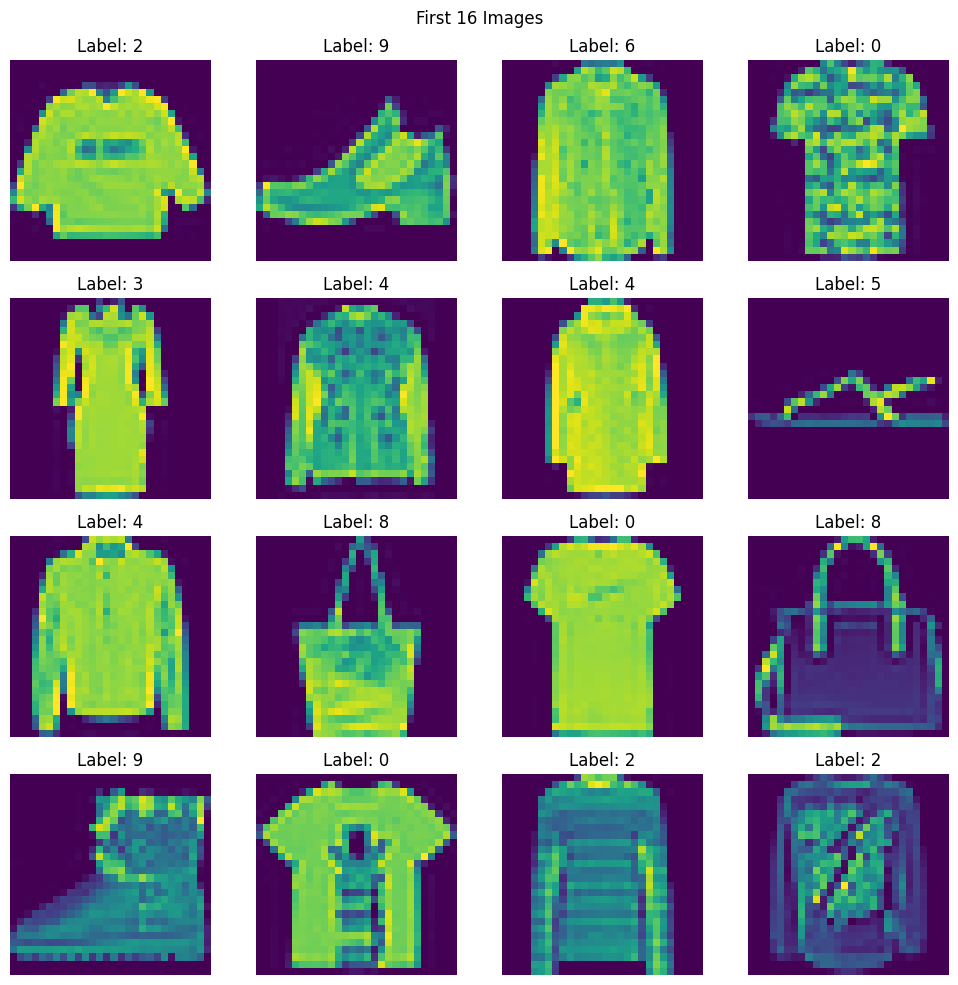

In [35]:
#first 16 images
fig, axes = plt.subplots(4, 4, figsize = (10, 10))
plt.suptitle("First 16 Images")

for i, ax in enumerate(axes.flat):
  img = df.iloc[i, 1:].values.reshape(28, 28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"Label: {df.iloc[i, 0]}")

plt.tight_layout()
plt.show()

In [36]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [37]:
#split into train test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [38]:
#normalize
X_train = X_train/255.0
X_test = X_test/255.0

In [39]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [41]:
#dataset and dataloader class

class CustomDataset(Dataset):

  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [42]:
#create train and test dataset object

train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [43]:
# create train and test data loader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [45]:
#Design NN architecture

class MyNeuralNetwork(nn.Module):

  def __init__(self, num_features):
    super().__init__()

    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, features):
    return self.model(features)

In [46]:
#hyperparameter
learning_rate = 0.1
epochs = 100

In [47]:
#instatiate the model
model = MyNeuralNetwork(X_train.shape[1])
model = model.to(device)

#loss
loss_function = nn.CrossEntropyLoss()

#optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [48]:
#training loop
import time
start = time.time()
for epoch in range(epochs):
  total_epoch_loss = 0

  for batch_features, batch_labels in train_loader:

    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    #forward prop
    output = model(batch_features)

    #loss
    loss = loss_function(output, batch_labels)

    #clear gradient
    optimizer.zero_grad()

    #backprop
    loss.backward()

    #update parameters
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f"Epoch: {epoch+1}, Loss: {avg_loss}")
end = time.time() - start
print(f"Total time taken to train the model: {end}")

Epoch: 1, Loss: 0.6417713933785757
Epoch: 2, Loss: 0.4307682518909375
Epoch: 3, Loss: 0.3863944115961591
Epoch: 4, Loss: 0.35952869733422993
Epoch: 5, Loss: 0.3381920256540179
Epoch: 6, Loss: 0.32129940266658863
Epoch: 7, Loss: 0.3067089657684167
Epoch: 8, Loss: 0.2977409450734655
Epoch: 9, Loss: 0.2854143363510569
Epoch: 10, Loss: 0.276634774133563
Epoch: 11, Loss: 0.2684109237380326
Epoch: 12, Loss: 0.2612845742702484
Epoch: 13, Loss: 0.25613858880723517
Epoch: 14, Loss: 0.24692446004475158
Epoch: 15, Loss: 0.24211124502619108
Epoch: 16, Loss: 0.23481669193009536
Epoch: 17, Loss: 0.227386101881663
Epoch: 18, Loss: 0.22249565460160375
Epoch: 19, Loss: 0.21721650839472811
Epoch: 20, Loss: 0.2137629295208802
Epoch: 21, Loss: 0.20851336499800285
Epoch: 22, Loss: 0.20336712603643536
Epoch: 23, Loss: 0.20077155179778736
Epoch: 24, Loss: 0.19347915250000855
Epoch: 25, Loss: 0.1900291856446614
Epoch: 26, Loss: 0.18329272096045315
Epoch: 27, Loss: 0.18060841896943747
Epoch: 28, Loss: 0.178136

In [49]:
#set model to eval mode

model.eval()

MyNeuralNetwork(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [51]:
#evaluation

total = 0
correct = 0
with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    output = model(batch_features)
    _, predicted = torch.max(output, 1)

    total = total + batch_labels.shape[0]
    correct = correct + (predicted == batch_labels).sum().item()
accuracy = (correct/total)*100
print(f"Total Accuracy is {accuracy:.2f}%")

Total Accuracy is 88.37%
